In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
pokemon = pd.read_csv('./data/pokemon.csv')

In [3]:
pokemon.head(10)

,id,species,generation_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,speed,special-attack,special-defense
0,1,bulbasaur,1,0.7,6.9,64,grass,poison,45,49,49,45,65,65
1,2,ivysaur,1,1.0,13.0,142,grass,poison,60,62,63,60,80,80
2,3,venusaur,1,2.0,100.0,236,grass,poison,80,82,83,80,100,100
3,4,charmander,1,0.6,8.5,62,fire,NaN,39,52,43,65,60,50
4,5,charmeleon,1,1.1,19.0,142,fire,NaN,58,64,58,80,80,65
5,6,charizard,1,1.7,90.5,240,fire,flying,78,84,78,100,109,85
6,7,squirtle,1,0.5,9.0,63,water,NaN,44,48,65,43,50,64
7,8,wartortle,1,1.0,22.5,142,water,NaN,59,63,80,58,65,80
8,9,blastoise,1,1.6,85.5,239,water,NaN,79,83,100,78,85,105
9,10,caterpie,1,0.3,2.9,39,bug,NaN,45,30,35,45,20,20


In [4]:
pokemon.shape

(807, 14)

In [13]:
pkm_types = pokemon.melt(id_vars=['id', 'species'], value_vars=['type_1', 'type_2'], var_name = 'type_level', value_name = 'type')

In [7]:
pkm_types.head(10)

,id,species,type_level,type
0,1,bulbasaur,type_1,grass
1,2,ivysaur,type_1,grass
2,3,venusaur,type_1,grass
3,4,charmander,type_1,fire
4,5,charmeleon,type_1,fire
5,6,charizard,type_1,fire
6,7,squirtle,type_1,water
7,8,wartortle,type_1,water
8,9,blastoise,type_1,water
9,10,caterpie,type_1,bug


In [8]:
pkm_counts = pkm_types['type'].value_counts()

In [9]:
pkm_counts

type
water       131
normal      109
flying       98
grass        97
psychic      82
bug          77
poison       66
fire         64
ground       64
rock         60
fighting     54
electric     48
fairy        47
steel        47
dark         46
dragon       45
ghost        43
ice          34
Name: count, dtype: int64

In [ ]:
pkm_type_order = pkm_counts.index

In [12]:
pkm_type_order

Index(['water', 'normal', 'flying', 'grass', 'psychic', 'bug', 'poison',
       'fire', 'ground', 'rock', 'fighting', 'electric', 'fairy', 'steel',
       'dark', 'dragon', 'ghost', 'ice'],
      dtype='object', name='type')

In [15]:
base_color = sb.color_palette()[0]

In [18]:
sb.countplot(data=pkm_types, y='type', color=base_color, order=pkm_type_order);

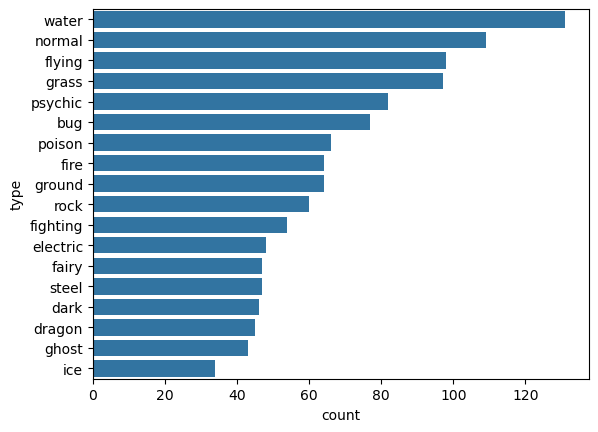

In [19]:
plt.show()

In [46]:
n_pkmn = pkm_types['type'].value_counts().sum()
print(n_pkmn)

1212


In [48]:
max_pkmn_types = pkm_counts[0]
print(max_pkmn_types)

131


/tmp/ipykernel_1287646/3702226269.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_pkmn_types = pkm_counts[0]


In [28]:
max_prop = max_pkmn_types / n_pkmn

In [29]:
print(max_prop)

0.10808580858085809


In [32]:
ticks_prop = np.arange(0, max_prop, 0.02)

In [33]:
ticks_prop

array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 ])

In [35]:
tick_names = ['{:0.2f}'.format(v) for v in ticks_prop]

In [36]:
tick_names

['0.00', '0.02', '0.04', '0.06', '0.08', '0.10']

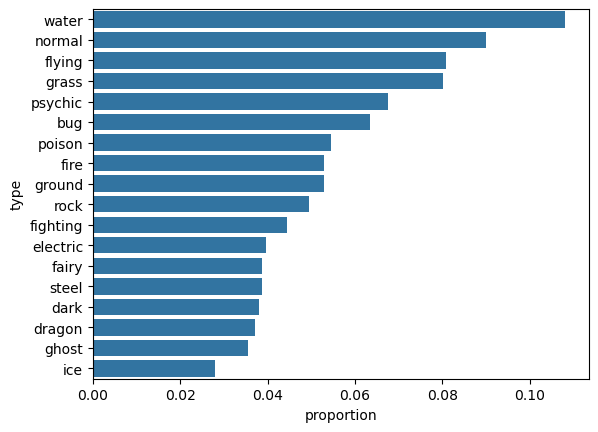

In [44]:
sb.countplot(data=pkm_types, y='type', color=base_color, order=pkm_type_order);
# change the label
plt.xticks(ticks_prop * n_pkmn, tick_names)
plt.xlabel('proportion');
plt.show()

Addtional Variation

In [50]:
base_color = sb.color_palette()[0]
sb.countplot(data=pkm_types, y='type', color=base_color, order=pkm_type_order);


In [59]:
pkm_counts.shape[0]

18

In [56]:
# Logic to print the proportion text on the bars
for i in range (pkm_counts.shape[0]):
    # Remember, type_counts contains the frequency of unique values in the `type` column in decreasing order.
    count = pkm_counts[i]
    # Convert count into a percentage, and then into string
    pct_string = '{:0.1f}'.format(100*count/n_pkmn)
    # Print the string value on the bar. 
    # Read more about the arguments of text() function [here](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.text.html)
    plt.text(count+1, i, pct_string, va='center')

/tmp/ipykernel_1287646/901030662.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  count = pkm_counts[i]


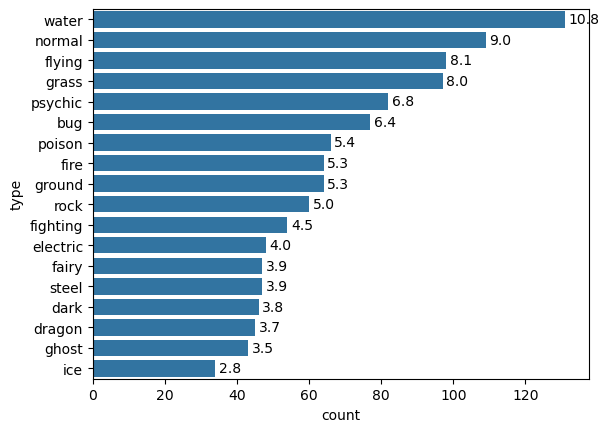

In [57]:
plt.show()

In [65]:
# Recalculating the type_counts just to have clarity.
type_counts = pkm_types['type'].value_counts()

# get the current tick locations and labels
locs, labels = plt.xticks(rotation=90) 

# loop through each pair of locations and labels
for loc, label in zip(locs, labels):
    print(label.get_text())
    # get the text property for the label to get the correct count
    count = type_counts[label.get_text()]
    pct_string = '{:0.1f}%'.format(100*count/n_pkmn)

    # print the annotation just below the top of the bar
    plt.text(loc, count+2, pct_string, ha = 'center', color = 'black')


0.0


KeyError: '0.0'

In [ ]:
from matplotlib import rcParams
# Specify the figure size in inches, for both X, and Y axes
rcParams['figure.figsize'] = 12,4

In [ ]:
plt.show()